In [3]:
!pip install scikit-learn numpy pandas matplotlib scipy

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [8]:
iris = datasets.load_iris()
wine = datasets.load_wine()
breast = datasets.load_breast_cancer()

X_iris = iris.data
y_iris = iris.target

X_wine = wine.data
y_wine = wine.target

X_bc = breast.data
y_bc = breast.target

In [9]:
X_iris_tr, X_iris_te, y_iris_tr, y_iris_te = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42
)

X_wine_tr, X_wine_te, y_wine_tr, y_wine_te = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42
)

X_bc_tr, X_bc_te, y_bc_tr, y_bc_te = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42
)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lr = Pipeline([
    ("sc", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000))
])

lr.fit(X_iris_tr, y_iris_tr)

pred = lr.predict(X_iris_te)

print("Logistic Regression Accuracy:", accuracy_score(y_iris_te, pred))

Logistic Regression Accuracy: 1.0


In [11]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=4, random_state=42)

dt.fit(X_wine_tr, y_wine_tr)

pred = dt.predict(X_wine_te)

print("Decision Tree Accuracy:", accuracy_score(y_wine_te, pred))

Decision Tree Accuracy: 0.9444444444444444


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_iris_tr, y_iris_tr)

pred = rf.predict(X_iris_te)

print("Random Forest Accuracy:", accuracy_score(y_iris_te, pred))

Random Forest Accuracy: 1.0


In [13]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1)

gb.fit(X_bc_tr, y_bc_tr)

pred = gb.predict(X_bc_te)

print("Gradient Boosting Accuracy:", accuracy_score(y_bc_te, pred))

Gradient Boosting Accuracy: 0.956140350877193


In [14]:
from sklearn.svm import SVC

svm = Pipeline([
    ("sc", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

svm.fit(X_iris_tr, y_iris_tr)

pred = svm.predict(X_iris_te)

print("SVM Accuracy:", accuracy_score(y_iris_te, pred))

SVM Accuracy: 1.0


In [15]:
from sklearn.neighbors import KNeighborsClassifier

knn = Pipeline([
    ("sc", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

knn.fit(X_iris_tr, y_iris_tr)

pred = knn.predict(X_iris_te)

print("KNN Accuracy:", accuracy_score(y_iris_te, pred))

KNN Accuracy: 1.0


In [16]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(X_iris_tr, y_iris_tr)

pred = gnb.predict(X_iris_te)

print("Naive Bayes Accuracy:", accuracy_score(y_iris_te, pred))

Naive Bayes Accuracy: 1.0


In [17]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

# Load dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

# Train/Test split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

results = []

# Test several polynomial degrees
for deg in [1, 2, 3]:

    model = Pipeline([
        ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
        ("sc", StandardScaler()),
        ("ridge", Ridge(alpha=1.0))
    ])

    model.fit(X_tr, y_tr)

    pred = model.predict(X_te)

    r2 = r2_score(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))

    results.append([deg, r2, rmse])

# Create table
table = pd.DataFrame(results, columns=["Degree", "R²", "RMSE"])

print(table)

   Degree        R²       RMSE
0       1  0.454147  53.777454
1       2  0.455779  53.696955
2       3 -0.111470  76.738116


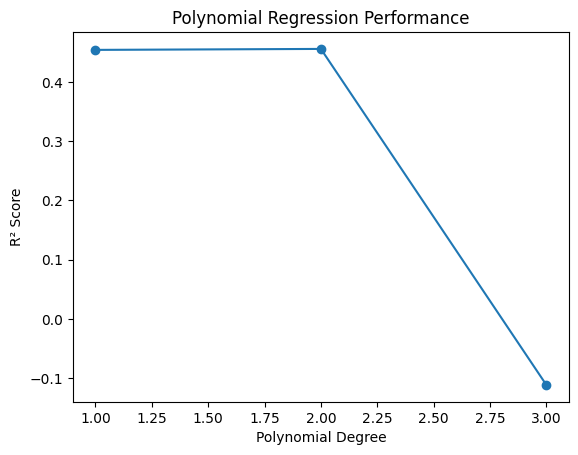

In [18]:
plt.plot(table["Degree"], table["R²"], marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")
plt.title("Polynomial Regression Performance")
plt.show()

In [19]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr_model = LinearRegression()

lr_model.fit(X_tr, y_tr)

pred = lr_model.predict(X_te)

print("Linear Regression R2:", r2_score(y_te, pred))

Linear Regression R2: 0.4526027629719195


In [20]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_tr, y_tr)

pred = ridge.predict(X_te)

print("Ridge R2:", r2_score(y_te, pred))

Ridge R2: 0.41915292635986545


In [21]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X_tr, y_tr)

pred = lasso.predict(X_te)

print("Lasso R2:", r2_score(y_te, pred))

Lasso R2: 0.4718547867276227


In [22]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)

elastic.fit(X_tr, y_tr)

pred = elastic.predict(X_te)

print("ElasticNet R2:", r2_score(y_te, pred))

ElasticNet R2: 0.09865421116113748


In [23]:
from sklearn.svm import SVR

svr = Pipeline([
    ("sc", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=100, epsilon=0.1))
])

svr.fit(X_tr, y_tr)

pred = svr.predict(X_te)

print("SVR R2:", r2_score(y_te, pred))

SVR R2: 0.5078392590548375


In [25]:
from sklearn.neural_network import MLPRegressor

mlp_reg = Pipeline([
    ("sc", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(128,64,32),
        max_iter=500,
        random_state=42
    ))
])

mlp_reg.fit(X_tr, y_tr)

pred = mlp_reg.predict(X_te)

print("MLP Regressor R2:", r2_score(y_te, pred))

MLP Regressor R2: 0.43636965740318734


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [27]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada.fit(X_bc_tr, y_bc_tr)

pred = ada.predict(X_bc_te)

print("AdaBoost Accuracy:", accuracy_score(y_bc_te, pred))

AdaBoost Accuracy: 0.9649122807017544


In [28]:
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    estimators=[
        ("rf", rf),
        ("gb", gb),
        ("knn", knn)
    ],
    final_estimator=LogisticRegression(max_iter=1000)
)

stack.fit(X_bc_tr, y_bc_tr)

pred = stack.predict(X_bc_te)

print("Stacking Accuracy:", accuracy_score(y_bc_te, pred))

Stacking Accuracy: 0.9649122807017544


In [31]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bag.fit(X_wine_tr, y_wine_tr)

pred = bag.predict(X_wine_te)

print("Bagging Accuracy:", accuracy_score(y_wine_te, pred))

Bagging Accuracy: 0.9722222222222222


In [32]:
from sklearn.linear_model import SGDClassifier

sgd = Pipeline([
    ("sc", StandardScaler()),
    ("sgd", SGDClassifier(loss="log_loss", max_iter=1000))
])

sgd.fit(X_iris_tr, y_iris_tr)

pred = sgd.predict(X_iris_te)

print("SGD Accuracy:", accuracy_score(y_iris_te, pred))

SGD Accuracy: 0.9666666666666667


In [33]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()

qda.fit(X_iris_tr, y_iris_tr)

pred = qda.predict(X_iris_te)

print("QDA Accuracy:", accuracy_score(y_iris_te, pred))

QDA Accuracy: 0.9666666666666667


In [34]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()

lda.fit(X_iris_tr, y_iris_tr)

pred = lda.predict(X_iris_te)

print("LDA Accuracy:", accuracy_score(y_iris_te, pred))

LDA Accuracy: 1.0


In [35]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42
)

et.fit(X_wine_tr, y_wine_tr)

pred = et.predict(X_wine_te)

print("Extra Trees Accuracy:", accuracy_score(y_wine_te, pred))

Extra Trees Accuracy: 1.0


In [36]:
from sklearn.neural_network import MLPClassifier

mlp = Pipeline([
    ("sc", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(256,128,64),
        activation="relu",
        max_iter=300,
        random_state=42
    ))
])

mlp.fit(X_iris_tr, y_iris_tr)

pred = mlp.predict(X_iris_te)

print("MLP Accuracy:", accuracy_score(y_iris_te, pred))

MLP Accuracy: 1.0


In [37]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada.fit(X_bc_tr, y_bc_tr)

pred = ada.predict(X_bc_te)

print("AdaBoost Accuracy:", accuracy_score(y_bc_te, pred))

AdaBoost Accuracy: 0.9649122807017544
